In [1]:
!pip install ultralytics kaggle opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.1 MB/s eta 0:00:00


In [2]:
!pip install -U kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.2/69.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


In [3]:
import kagglehub
import os

DATASET_PATH = kagglehub.dataset_download(
    "mahyeks/pothrgbd-rgb-and-depth-images-of-potholes"
)

print("Dataset root:", DATASET_PATH)

100%|██████████| 125M/125M [00:05<00:00, 23.3MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/mahyeks/pothrgbd-rgb-and-depth-images-of-potholes/versions/1


In [4]:
def find_pothole_root(base):
    for root, dirs, files in os.walk(base):
        if "PUBLIC POTHOLE DATASET" in dirs:
            return os.path.join(root, "PUBLIC POTHOLE DATASET")
    return None

POTHOLE_ROOT = find_pothole_root(DATASET_PATH)
print("POTHOLE_ROOT:", POTHOLE_ROOT)

POTHOLE_ROOT: /root/.cache/kagglehub/datasets/mahyeks/pothrgbd-rgb-and-depth-images-of-potholes/versions/1/PUBLIC POTHOLE DATASET


In [5]:
import os

print("Subfolders:", os.listdir(POTHOLE_ROOT))

Subfolders: ['images', 'depths', 'labels']


In [6]:
import os, random, shutil

IMG_DIR = os.path.join(POTHOLE_ROOT, "images")
LBL_DIR = os.path.join(POTHOLE_ROOT, "labels")

assert os.path.exists(IMG_DIR), "❌ images folder not found"
assert os.path.exists(LBL_DIR), "❌ labels folder not found"

# output dataset
for s in ["train", "val"]:
    os.makedirs(f"dataset/images/{s}", exist_ok=True)
    os.makedirs(f"dataset/labels/{s}", exist_ok=True)

images = [f for f in os.listdir(IMG_DIR) if f.endswith((".jpg",".png"))]
random.shuffle(images)

split = int(0.8 * len(images))
train_imgs = images[:split]
val_imgs = images[split:]

def copy_data(img_list, split):
    for img in img_list:
        name = os.path.splitext(img)[0]
        shutil.copy(os.path.join(IMG_DIR, img),
                    f"dataset/images/{split}/{img}")
        shutil.copy(os.path.join(LBL_DIR, name + ".txt"),
                    f"dataset/labels/{split}/{name}.txt")

copy_data(train_imgs, "train")
copy_data(val_imgs, "val")

print("Dataset split complete")

Dataset split complete


In [7]:
import yaml
import os

data_yaml = {
    "path": os.path.abspath("dataset"),
    "train": "images/train",
    "val": "images/val",
    "nc": 1,
    "names": ["pothole"]
}

with open("dataset/data.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("✅ data.yaml created")
print(data_yaml)

✅ data.yaml created
{'path': '/content/dataset', 'train': 'images/train', 'val': 'images/val', 'nc': 1, 'names': ['pothole']}


In [8]:
import os

print("Train images:", len(os.listdir("dataset/images/train")))
print("Val images:", len(os.listdir("dataset/images/val")))
print("Train labels:", len(os.listdir("dataset/labels/train")))
print("Val labels:", len(os.listdir("dataset/labels/val")))

Train images: 800
Val images: 200
Train labels: 800
Val labels: 200


In [9]:
!pip install -U ultralytics

In [11]:
from ultralytics import YOLO
import torch

model = YOLO("yolov8n.pt")

model.train(
    data="dataset/data.yaml",
    epochs=10,
    imgsz=64,
    batch=2,
    device="cpu",
    workers=0,
    cache=False
)

Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e2ef02da600>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [12]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1503.5±446.2 MB/s, size: 76.5 KB)
val: Scanning /content/dataset/labels/val.cache... 200 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 39.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.4it/s 5.4s
                   all        200        210      0.726      0.743      0.788      0.445
Speed: 0.1ms preprocess, 12.5ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e2ee6d6ec00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision

In [20]:
import os

best_model_path = None

for root, dirs, files in os.walk("runs"):
    if "best.pt" in files:
        best_model_path = os.path.join(root, "best.pt")
        print("Found best model:", best_model_path)
        break

assert best_model_path is not None, "Not found best.pt"

Found best model: runs/detect/train2/weights/best.pt


In [21]:
from ultralytics import YOLO

model = YOLO(best_model_path)
print("Model loaded")

Model loaded


In [22]:
import random

val_dir = "dataset/images/val"
test_image = os.path.join(val_dir, random.choice(os.listdir(val_dir)))

print("Test image:", test_image)

Test image: dataset/images/val/20250227_172528_color_png.rf.b709d755fd36a74ba8be4b9e8166a19c.jpg


In [23]:
results = model(test_image)


image 1/1 /content/dataset/images/val/20250227_172528_color_png.rf.b709d755fd36a74ba8be4b9e8166a19c.jpg: 64x64 1 pothole, 49.1ms
Speed: 1.2ms preprocess, 49.1ms inference, 1.7ms postprocess per image at shape (1, 3, 64, 64)


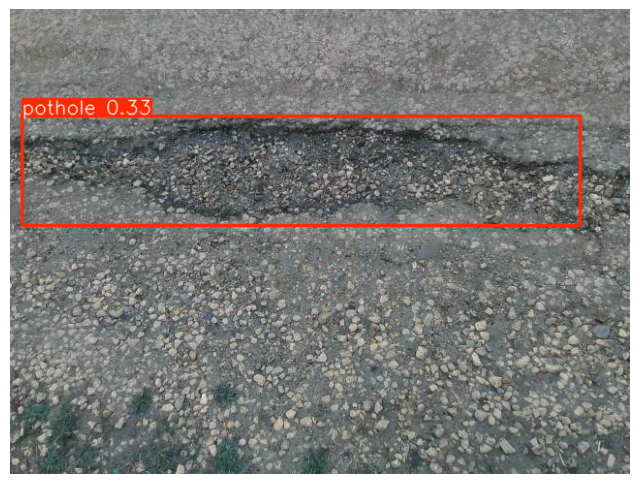

In [25]:
import matplotlib.pyplot as plt

img = results[0].plot()   # วาด bbox ลงบนภาพ

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [26]:
for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print(f"Class: {cls}, Confidence: {conf:.3f}, Box: {xyxy}")

Class: 0, Confidence: 0.328, Box: [12.500495910644531, 110.3091049194336, 588.5715942382812, 223.83090209960938]
